# Notebook 8 - Battery Sentinel Twin Training

This notebook trains the predictive core of Battery Sentinel: a compact battery twin that learns nominal charging dynamics from the Battery Sentinel dataset and produces residuals for later uncertainty routing.


## Link with the original project

The original six notebooks compare three forward-noise families in a diffusion setting. Battery Sentinel reuses that tri-noise interpretation in a time-series setting:

- learn expected battery behavior under nominal conditions,
- compare observed behavior to the prediction,
- use the residual geometry to infer whether the deviation is Gaussian-like, Uniform-like, or Laplace-like.


In [1]:
!pip install -q torch torchvision matplotlib pandas numpy seaborn


In [2]:
import json
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

IN_COLAB = False
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    drive = None

FOUNDATION_DRIVE_DIR = '/content/drive/MyDrive/diffusion_noise_project'
FOUNDATION_DIR = '/content/foundation_diffusion_noise_project'
BATTERY_ROOT = '/content/drive/MyDrive/battery_sentinel'

if IN_COLAB:
    if not os.path.exists(FOUNDATION_DIR):
        if not os.path.exists(FOUNDATION_DRIVE_DIR):
            raise FileNotFoundError(f'Foundation artifacts not found in Drive: {FOUNDATION_DRIVE_DIR}')
        shutil.copytree(FOUNDATION_DRIVE_DIR, FOUNDATION_DIR)
else:
    FOUNDATION_DIR = str((Path.cwd() / 'diffusion_noise_project' / 'diffusion_noise_project').resolve())
    BATTERY_ROOT = str((Path.cwd() / 'diffusion_noise_project' / 'diffusion_noise_project' / 'battery_sentinel').resolve())

DATA_DIR = os.path.join(BATTERY_ROOT, 'data')
LOG_DIR = os.path.join(BATTERY_ROOT, 'logs')
FIGURE_DIR = os.path.join(BATTERY_ROOT, 'figures')
MODEL_DIR = os.path.join(BATTERY_ROOT, 'models')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = DEVICE.type == 'cuda'
print('Battery Sentinel root:', BATTERY_ROOT)
print('Device:', DEVICE)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Battery Sentinel root: /content/drive/MyDrive/battery_sentinel
Device: cuda


In [3]:
TRAIN_CONFIG = {
    'seed': 42,
    'window': 24,
    'stride_train': 4,
    'stride_eval': 2,
    'batch_size': 256,
    'hidden_dim': 64,
    'num_layers': 2,
    'dropout': 0.10,
    'num_epochs': 12,
    'lr': 1e-3,
    'weight_decay': 1e-5,
}
TRAIN_CONFIG


{'seed': 42,
 'window': 24,
 'stride_train': 4,
 'stride_eval': 2,
 'batch_size': 256,
 'hidden_dim': 64,
 'num_layers': 2,
 'dropout': 0.1,
 'num_epochs': 12,
 'lr': 0.001,
 'weight_decay': 1e-05}

In [4]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def load_dataset():
    payload = np.load(os.path.join(DATA_DIR, 'battery_sentinel_dataset.npz'), allow_pickle=True)
    return {
        'true_series': payload['true_series'].astype(np.float32),
        'observed_series': payload['observed_series'].astype(np.float32),
        'regime_labels': payload['regime_labels'],
        'train_indices': payload['train_indices'],
        'val_indices': payload['val_indices'],
        'test_indices': payload['test_indices'],
    }

def build_windows(dataset, indices, window, stride):
    inputs, targets, regimes, session_ids = [], [], [], []
    target_idx = [0, 1, 3]  # soc, voltage, temperature
    for session_id in indices:
        observed = dataset['observed_series'][session_id]
        true = dataset['true_series'][session_id]
        regime = str(dataset['regime_labels'][session_id])
        for start in range(0, observed.shape[0] - window - 1, stride):
            end = start + window
            inputs.append(observed[start:end])
            targets.append(true[end, target_idx])
            regimes.append(regime)
            session_ids.append(int(session_id))
    return np.stack(inputs).astype(np.float32), np.stack(targets).astype(np.float32), np.array(regimes), np.array(session_ids)

class BatteryTwinGRU(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, num_layers: int, dropout: float):
        super().__init__()
        self.gru = nn.GRU(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers, dropout=dropout if num_layers > 1 else 0.0, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, 3))
    def forward(self, x):
        output, _ = self.gru(x)
        return self.head(output[:, -1])


In [6]:
set_seed(TRAIN_CONFIG['seed'])
dataset = load_dataset()

x_train_all, y_train_all, regimes_train_all, _ = build_windows(dataset, dataset['train_indices'], TRAIN_CONFIG['window'], TRAIN_CONFIG['stride_train'])
x_val_all, y_val_all, regimes_val_all, _ = build_windows(dataset, dataset['val_indices'], TRAIN_CONFIG['window'], TRAIN_CONFIG['stride_eval'])
x_test_all, y_test_all, regimes_test_all, sessions_test = build_windows(dataset, dataset['test_indices'], TRAIN_CONFIG['window'], TRAIN_CONFIG['stride_eval'])

train_mask = regimes_train_all == 'gaussian'
val_mask = regimes_val_all == 'gaussian'

x_train = x_train_all[train_mask]
y_train = y_train_all[train_mask]
x_val = x_val_all[val_mask]
y_val = y_val_all[val_mask]

x_mean = x_train.mean(axis=(0, 1), keepdims=True)
x_std = x_train.std(axis=(0, 1), keepdims=True) + 1e-6
y_mean = y_train.mean(axis=0, keepdims=True)
y_std = y_train.std(axis=0, keepdims=True) + 1e-6

x_train_n = (x_train - x_mean) / x_std
x_val_n = (x_val - x_mean) / x_std
x_test_n = (x_test_all - x_mean) / x_std

y_train_n = (y_train - y_mean) / y_std
y_val_n = (y_val - y_mean) / y_std

audit = {
    'train_windows_total': int(len(x_train_all)),
    'train_windows_nominal_only': int(len(x_train)),
    'val_windows_nominal_only': int(len(x_val)),
    'test_windows_total': int(len(x_test_all)),
}
audit


{'train_windows_total': 26182,
 'train_windows_nominal_only': 8840,
 'val_windows_nominal_only': 3328,
 'test_windows_total': 11232}

In [9]:
import time

train_loader = DataLoader(TensorDataset(torch.from_numpy(x_train_n), torch.from_numpy(y_train_n)), batch_size=TRAIN_CONFIG['batch_size'], shuffle=True, pin_memory=PIN_MEMORY)
val_loader = DataLoader(TensorDataset(torch.from_numpy(x_val_n), torch.from_numpy(y_val_n)), batch_size=TRAIN_CONFIG['batch_size'], shuffle=False, pin_memory=PIN_MEMORY)

model = BatteryTwinGRU(input_dim=x_train_n.shape[-1], hidden_dim=TRAIN_CONFIG['hidden_dim'], num_layers=TRAIN_CONFIG['num_layers'], dropout=TRAIN_CONFIG['dropout']).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=TRAIN_CONFIG['lr'], weight_decay=TRAIN_CONFIG['weight_decay'])
criterion = nn.MSELoss()

history = []
best_val = float('inf')
best_state = None
start_time = time.time()

for epoch in range(1, TRAIN_CONFIG['num_epochs'] + 1):
    model.train()
    train_losses = []
    for xb, yb in tqdm(train_loader, desc=f'Epoch {epoch}', leave=False):
        xb = xb.to(DEVICE, non_blocking=PIN_MEMORY)
        yb = yb.to(DEVICE, non_blocking=PIN_MEMORY)
        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(float(loss.item()))

    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE, non_blocking=PIN_MEMORY)
            yb = yb.to(DEVICE, non_blocking=PIN_MEMORY)
            pred = model(xb)
            val_losses.append(float(criterion(pred, yb).item()))

    train_loss = float(np.mean(train_losses))
    val_loss = float(np.mean(val_losses))
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss, 'elapsed_s': float(time.time() - start_time)})
    print(f'Epoch {epoch:02d} | train={train_loss:.5f} | val={val_loss:.5f}')
    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)


Epoch 1:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 01 | train=0.51559 | val=0.08570


Epoch 2:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 02 | train=0.05365 | val=0.03882


Epoch 3:   0%|          | 0/35 [00:00<?, ?it/s]

...

Epoch 11:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 11 | train=0.01329 | val=0.01125


Epoch 12:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 12 | train=0.01278 | val=0.01103


<All keys matched successfully>

In [10]:
model_path = os.path.join(MODEL_DIR, 'battery_twin_gru.pt')
scaler_path = os.path.join(MODEL_DIR, 'battery_twin_scalers.npz')
torch.save({'model_state': model.state_dict(), 'train_config': TRAIN_CONFIG}, model_path)
np.savez_compressed(scaler_path, x_mean=x_mean, x_std=x_std, y_mean=y_mean, y_std=y_std)

with torch.no_grad():
    preds_test_n = model(torch.from_numpy(x_test_n).to(DEVICE, non_blocking=PIN_MEMORY)).cpu().numpy()
    preds_test = preds_test_n * y_std + y_mean
    residuals = preds_test - y_test_all

rows = []
for regime in ['gaussian', 'uniform', 'laplace']:
    mask = regimes_test_all == regime
    subset = residuals[mask]
    rows.append({
        'regime': regime,
        'mae_soc': float(np.mean(np.abs(subset[:, 0]))),
        'mae_voltage': float(np.mean(np.abs(subset[:, 1]))),
        'mae_temperature': float(np.mean(np.abs(subset[:, 2]))),
        'rmse_joint': float(np.sqrt(np.mean(subset ** 2))),
        'num_windows': int(mask.sum()),
    })

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(os.path.join(LOG_DIR, 'twin_regime_metrics.csv'), index=False)
with open(os.path.join(LOG_DIR, 'twin_training_summary.json'), 'w', encoding='utf-8') as handle:
    json.dump({'train_config': TRAIN_CONFIG, 'dataset_audit': audit, 'history': history, 'test_metrics': rows, 'model_path': model_path, 'scaler_path': scaler_path}, handle, indent=2)
metrics_df


,regime,mae_soc,mae_voltage,mae_temperature,rmse_joint,num_windows
0,gaussian,0.004712,0.052260,0.112113,0.107993,3952
1,uniform,0.004656,0.055057,0.124822,0.118703,3640
2,laplace,0.004681,0.070593,0.272685,0.244464,3640


/tmp/ipykernel_4478/97440546.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='regime', y='joint_abs_residual', ax=axes[1], palette=['#355c7d', '#6c8ead', '#c06c84'])


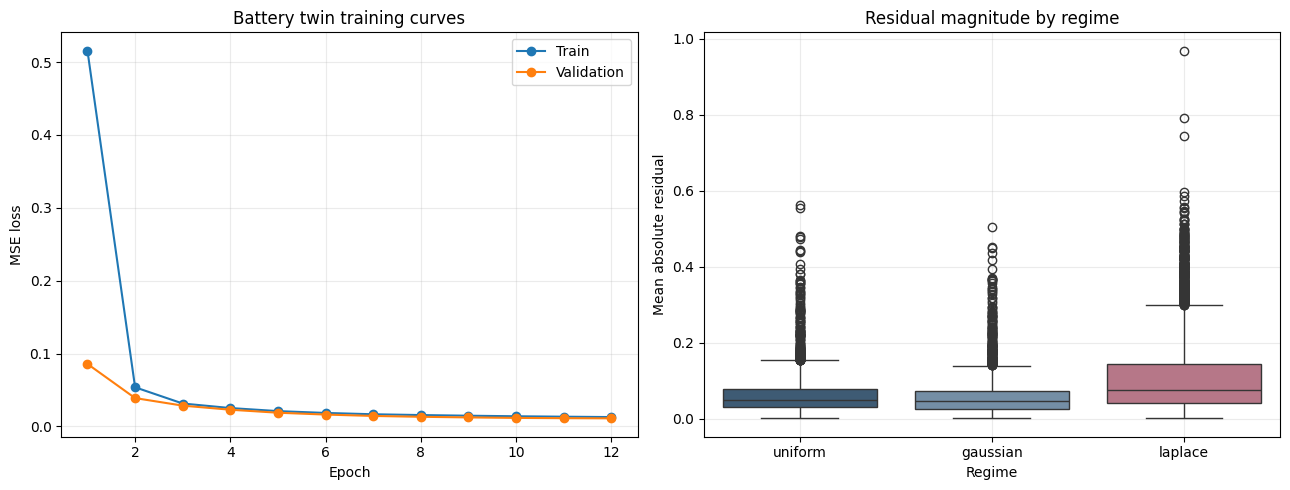

Saved: /content/drive/MyDrive/battery_sentinel/figures/battery_twin_training_curves.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
loss_df = pd.DataFrame(history)
axes[0].plot(loss_df['epoch'], loss_df['train_loss'], marker='o', label='Train')
axes[0].plot(loss_df['epoch'], loss_df['val_loss'], marker='o', label='Validation')
axes[0].set_title('Battery twin training curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE loss')
axes[0].grid(alpha=0.25)
axes[0].legend()

plot_df = pd.DataFrame({'regime': regimes_test_all, 'joint_abs_residual': np.abs(residuals).mean(axis=1)})
sns.boxplot(data=plot_df, x='regime', y='joint_abs_residual', ax=axes[1], palette=['#355c7d', '#6c8ead', '#c06c84'])
axes[1].set_title('Residual magnitude by regime')
axes[1].set_xlabel('Regime')
axes[1].set_ylabel('Mean absolute residual')
axes[1].grid(alpha=0.25)

fig.tight_layout()
curve_path = os.path.join(FIGURE_DIR, 'battery_twin_training_curves.png')
fig.savefig(curve_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', curve_path)


## Expected result

After this notebook, Battery Sentinel has a trained predictive twin and saved calibration material:

- `battery_sentinel/models/battery_twin_gru.pt`
- `battery_sentinel/models/battery_twin_scalers.npz`
- `battery_sentinel/logs/twin_training_summary.json`
- `battery_sentinel/logs/twin_regime_metrics.csv`
- `battery_sentinel/figures/battery_twin_training_curves.png`

The next notebook uses these residuals to decide whether the deviation looks Gaussian, Uniform, or Laplace.
